# FABLE Pyculator 2020 Notebook Loop

This notebook demonstrates the first FABLE Pyculator loop for the public 2020 FABLE-C workbook and an ignored local Modelwright-generated Python model.

Use the VSCode notebook kernel from the `.venv` created in the `fable-pyculator` repository root. The setup cell prints the active Python executable and warns if the selected kernel does not appear to be that repo-local environment.

Expected local artifacts, resolved relative to the `fable-pyculator` repository root:

- `tmp/private-workbooks/2020_Open_FABLECalculator.xlsx`
- `tmp/generated-models/fable-2020/generated_fable_2020_model.py`

If the generated model is missing but a sibling Modelwright checkout exists, this notebook can materialize the local compressed Modelwright example into the ignored FABLE Pyculator `tmp/` path. If required artifacts are still unavailable, the notebook reports that status and skips execution cells instead of failing during setup.


In [1]:
from pathlib import Path
import sys
import contextlib
import io
import lzma
import shutil
import warnings

from IPython.display import Markdown, display

import matplotlib.pyplot as plt

from fable_pyculator import (
    DEFAULT_2020_GENERATED_MODEL_PATH,
    DEFAULT_2020_WORKBOOK_PATH,
    build_2020_notebook_spec,
    load_generated_model,
    output_table_frame,
    plot_headline,
    run_notebook_loop,
)

warnings.filterwarnings("ignore", message="wmf image format is not supported.*")
warnings.filterwarnings("ignore", message="Data Validation extension is not supported.*")


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    candidates.extend(parent / "fable-pyculator" for parent in [start, *start.parents])
    for candidate in candidates:
        pyproject = candidate / "pyproject.toml"
        if pyproject.exists() and "name = \"fable-pyculator\"" in pyproject.read_text(encoding="utf-8"):
            return candidate
    raise RuntimeError("Could not find the fable-pyculator repository root.")


notebook_working_dir = Path.cwd().resolve()
repo_root = find_repo_root(notebook_working_dir)
expected_kernel_prefix = repo_root / ".venv"
active_python = Path(sys.executable)
active_prefix = Path(sys.prefix).resolve()
using_repo_venv = active_prefix == expected_kernel_prefix
workbook_path = repo_root / DEFAULT_2020_WORKBOOK_PATH
generated_model_path = repo_root / DEFAULT_2020_GENERATED_MODEL_PATH
modelwright_archive = repo_root.parent / "modelwright" / "examples" / "fable_2020" / "generated_fable_2020_model.py.xz"

if not generated_model_path.exists() and modelwright_archive.exists():
    generated_model_path.parent.mkdir(parents=True, exist_ok=True)
    with lzma.open(modelwright_archive, "rb") as source, generated_model_path.open("wb") as target:
        shutil.copyfileobj(source, target)

missing = [path for path in (workbook_path, generated_model_path) if not path.exists()]
ARTIFACTS_READY = not missing

if ARTIFACTS_READY:
    display(Markdown(
        f"Notebook working directory: `{notebook_working_dir}`\n\n"
        f"Resolved fable-pyculator repo root: `{repo_root}`\n\n"
        f"Active Python: `{active_python}`\n\n"
        f"Active environment prefix: `{active_prefix}`\n\n"
        f"Expected VSCode kernel prefix: `{expected_kernel_prefix}`\n\n"
        + ("" if using_repo_venv else "**Warning:** select the repo-local `.venv` kernel in VSCode before running model cells.\n\n")
        + f"Workbook: `{workbook_path}`\n\n"
        f"Generated model: `{generated_model_path}`"
    ))
else:
    display(Markdown(
        f"Notebook working directory: `{notebook_working_dir}`\n\n"
        f"Resolved fable-pyculator repo root: `{repo_root}`\n\n"
        f"Active Python: `{active_python}`\n\n"
        f"Active environment prefix: `{active_prefix}`\n\n"
        f"Expected VSCode kernel prefix: `{expected_kernel_prefix}`\n\n"
        + ("" if using_repo_venv else "**Warning:** select the repo-local `.venv` kernel in VSCode before running model cells.\n\n")
        + "Required local artifacts are missing, so execution cells will be skipped.\n\n"
        + "\n".join(f"- `{path}`" for path in missing)
        + "\n\nRestore the workbook under `tmp/private-workbooks/` and the generated model under "
        + "`tmp/generated-models/fable-2020/`, then rerun the notebook."
    ))


Notebook working directory: `/srv/shared-data/gep/jupyterhub14-projects/fable-pyculator/examples/notebooks`

Resolved fable-pyculator repo root: `/srv/shared-data/gep/jupyterhub14-projects/fable-pyculator`

Active Python: `/srv/shared-data/gep/jupyterhub14-projects/fable-pyculator/.venv/bin/python`

Active environment prefix: `/srv/shared-data/gep/jupyterhub14-projects/fable-pyculator/.venv`

Expected VSCode kernel prefix: `/srv/shared-data/gep/jupyterhub14-projects/fable-pyculator/.venv`

Workbook: `/srv/shared-data/gep/jupyterhub14-projects/fable-pyculator/tmp/private-workbooks/2020_Open_FABLECalculator.xlsx`

Generated model: `/srv/shared-data/gep/jupyterhub14-projects/fable-pyculator/tmp/generated-models/fable-2020/generated_fable_2020_model.py`

## Build the Workbook-Derived Spec

The spec discovers the 2020 scenario selection controls, canonical output tables, and curated FOOD/LAND/GHG/WATER headline series.

In [2]:
if ARTIFACTS_READY:
    spec = build_2020_notebook_spec(workbook_path)
    display((len(spec.selection_controls), len(spec.output_tables), len(spec.headline_series)))
else:
    spec = None
    display(Markdown("Skipped: local workbook/model artifacts are not ready."))


(16, 14, 4)

## Choose Scenario Selections

Selection values are named by discovered table names such as `gdp_scen`. Each value expands to the workbook marker cells that clear all rows except the chosen option.

In [3]:
selections = {
    "gdp_scen": "SSP1",
}

if ARTIFACTS_READY:
    display(spec.input_mapping(selections))
else:
    display(selections)


{'SCENARIOS selection!A20': 'x',
 'SCENARIOS selection!A21': None,
 'SCENARIOS selection!A22': None}

## Run the Generated Model

The generated model is imported from ignored `tmp/` space. The wrapper returns raw run metadata, selected output tables, headline DataFrames, and optional matplotlib figures.

In [4]:
if ARTIFACTS_READY:
    generated_model = load_generated_model(generated_model_path)
    progress_output = io.StringIO()
    with contextlib.redirect_stdout(progress_output):
        result = run_notebook_loop(
            generated_model,
            spec,
            selections,
            scenario_name="ssp1_demo",
            include_figures=False,
        )
    plt.close("all")
    progress_lines = [line for line in progress_output.getvalue().splitlines() if line.strip()]
    display(Markdown(
        f"Scenario `{result.run.scenario_name}` completed with `{len(result.run.inputs)}` inputs "
        f"and `{len(result.run.values)}` returned cell values. "
        f"Suppressed `{len(progress_lines)}` generated-model progress lines."
    ))
else:
    result = None
    display(Markdown("Skipped: local workbook/model artifacts are not ready."))


Scenario `ssp1_demo` completed with `3` inputs and `281744` returned cell values. Suppressed `29` generated-model progress lines.

## Inspect Rendered Outputs

The model run rendered all discovered output tables and curated headline frames, so later cells can inspect additional outputs without rerunning the model.


In [5]:
if result is not None:
    display(Markdown(
        "**Output tables**\n\n"
        + "\n".join(f"- `{name}`" for name in sorted(result.output_tables))
        + "\n\n**Headline frames**\n\n"
        + "\n".join(f"- `{name}`" for name in sorted(result.headline_frames))
    ))
else:
    display(Markdown("Skipped: run the model first."))


**Output tables**

- `biodiversity_resultsbiodiv`
- `biodiversity_resultsprotectedareas`
- `biodiversity_resultstargetbiodiv`
- `food_results_diets`
- `food_total_results_diets`
- `ghg_resultsghg`
- `land_resultscroparea`
- `land_resultsland`
- `production_resultsprod`
- `production_totalresultsprod`
- `trade_resultstrade`
- `trade_totalresultstrade`
- `water_resultswf`
- `water_totalresultswf`

**Headline frames**

- `food_total_kcal_feas`
- `ghg_total_co2e`
- `land_total_area`
- `water_total_footprint`

In [6]:
if result is not None:
    display(result.output_tables["ghg_resultsghg"].head())
else:
    display(Markdown("Skipped: run the model first."))


,Year,TotalCO2e,FAOTotalCO2e,AgriCO2e,AgriCO2,AgriN2O,TotalCH4,HistLiveCO2e,HistLiveN2O,HistLiveCH4,...,HistCropCH4,CropCO2e,CropCO2,CropN2O,CropCH4,LandCO2e,DeforCO2,OtherLandCO2,LandSeq,BiofuelSavings
row,,,,,,,,,,,,,,,,,,,,,
2000,None,443.336290,508.357810,444.659499,40.822193,116.606466,287.230839,230.962507,69.125472,161.837036,...,168.188289,277.359790,40.822193,69.427557,167.110039,0.000000,0.000000,0.000000,0.000000,-1.323209
2005,None,419.177945,539.723439,459.110873,42.914221,121.270062,294.926591,251.633918,75.633296,176.000622,...,173.545651,285.217687,42.914221,72.509406,169.794060,-38.179963,14.372706,3.105325,-55.657994,-1.752965
2010,None,572.716819,598.314166,516.956452,44.579276,141.427288,330.949889,284.234649,85.439858,198.794791,...,186.889866,310.084511,44.579276,83.067803,182.437432,57.658478,60.027338,53.289134,-55.657994,-1.898111
2015,None,582.030546,NaN,530.941077,45.607879,145.766485,339.566713,0.000000,0.000000,0.000000,...,0.000000,315.109740,45.607879,84.966272,184.535589,53.317873,58.280573,50.695294,-55.657994,-2.228404
2020,None,548.129037,NaN,541.207964,46.182211,148.485156,346.540597,0.000000,0.000000,0.000000,...,0.000000,321.411646,46.182211,86.656169,188.573266,9.528738,34.375662,30.811071,-55.657994,-2.607665


In [7]:
if result is not None:
    display(output_table_frame(result.run, "ghg_resultsghg", column_flavour_tags="OUTPUT-*").head())
else:
    display(Markdown("Skipped: run the model first."))


,Year,LiveN2O,LiveCH4,CropCO2,CropN2O,CropCH4,DeforCO2,OtherLandCO2,LandSeq,BiofuelSavings
row,,,,,,,,,,
2000,None,47.178909,120.120800,40.822193,69.427557,167.110039,0.000000,0.000000,0.000000,-1.323209
2005,None,48.760655,125.132531,42.914221,72.509406,169.794060,14.372706,3.105325,-55.657994,-1.752965
2010,None,58.359485,148.512456,44.579276,83.067803,182.437432,60.027338,53.289134,-55.657994,-1.898111
2015,None,60.800213,155.031124,45.607879,84.966272,184.535589,58.280573,50.695294,-55.657994,-2.228404
2020,None,61.828988,157.967330,46.182211,86.656169,188.573266,34.375662,30.811071,-55.657994,-2.607665


In [8]:
if result is not None:
    display(result.headline_frames["water_total_footprint"])
else:
    display(Markdown("Skipped: run the model first."))


,name,label,group,year,value,unit,cell_refs,description
0,water_total_footprint,Total water footprint,WATER,2000,4.353998e+05,None,"(WATER!S16, WATER!T16, WATER!U16, WATER!V16, W...",None
1,water_total_footprint,Total water footprint,WATER,2005,5.542217e+05,None,"(WATER!S17, WATER!T17, WATER!U17, WATER!V17, W...",None
2,water_total_footprint,Total water footprint,WATER,2010,6.232975e+05,None,"(WATER!S18, WATER!T18, WATER!U18, WATER!V18, W...",None
3,water_total_footprint,Total water footprint,WATER,2015,6.663915e+05,None,"(WATER!S19, WATER!T19, WATER!U19, WATER!V19, W...",None
4,water_total_footprint,Total water footprint,WATER,2020,7.005597e+05,None,"(WATER!S20, WATER!T20, WATER!U20, WATER!V20, W...",None
5,water_total_footprint,Total water footprint,WATER,2025,7.489715e+05,None,"(WATER!S21, WATER!T21, WATER!U21, WATER!V21, W...",None
6,water_total_footprint,Total water footprint,WATER,2030,8.110215e+05,None,"(WATER!S22, WATER!T22, WATER!U22, WATER!V22, W...",None
7,water_total_footprint,Total water footprint,WATER,2035,8.883283e+05,None,"(WATER!S23, WATER!T23, WATER!U23, WATER!V23, W...",None
8,water_total_footprint,Total water footprint,WATER,2040,9.803875e+05,None,"(WATER!S24, WATER!T24, WATER!U24, WATER!V24, W...",None
9,water_total_footprint,Total water footprint,WATER,2045,1.050992e+06,None,"(WATER!S25, WATER!T25, WATER!U25, WATER!V25, W...",None


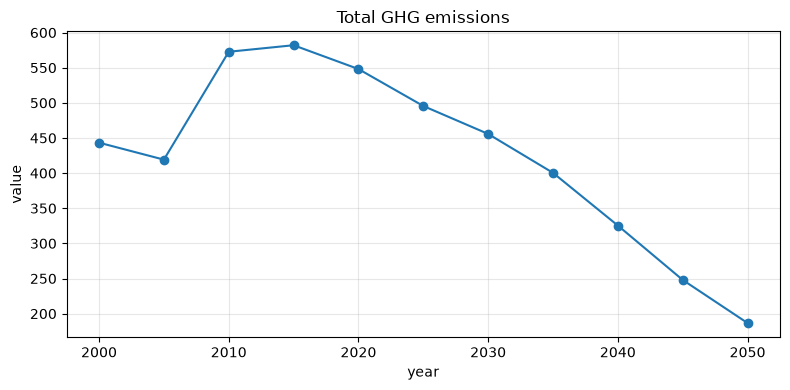

In [9]:
if result is not None:
    figure = plot_headline(result.run, "ghg_total_co2e")
    display(figure)
    plt.close(figure)
else:
    display(Markdown("Skipped: run the model first."))
